# Hierarchical Clustering Analysis of Italian Rap Music

## Project Overview

This notebook performs a comprehensive **hierarchical clustering analysis** on a dataset of **Italian rap tracks** to discover natural groupings and musical patterns within the Italian hip-hop scene.

### Dataset Characteristics
- **Dataset**: `merged_dataset_clean.csv`
- **Features**: 14 carefully engineered features capturing:
  - **Linguistic properties**: Lyrical complexity, profanity
  - **Musical attributes**: Duration, percussiveness, harmonic richness
  - **Genre-specific metrics**: Trap, Drill, Boom Bap, Cloud Rap indices
  - **Metadata**: Popularity, years since release, artist career longevity

### Analysis Methodology
1. **Data Preparation**: Loading, cleaning, and standardization
2. **Method Comparison**: Evaluating Ward, Single, Complete, and Average linkage algorithms
3. **Optimal Cluster Selection**: Using Silhouette Score and Elbow Method
4. **Cluster Interpretation**: Profiling each cluster's characteristics
5. **Visualization**: Multiple dimensionality reduction techniques (PCA, t-SNE, UMAP)

### Research Questions
- What are the main musical subgroups within Italian rap?
- How do linguistic and musical features differ across clusters?
- Can we identify distinct genres (Trap, Drill, Traditional Hip-Hop, etc.)?
- What characteristics define popular vs. niche music in Italian rap?

---

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Libraries for Clustering and Distances
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

from sklearn.manifold import TSNE
import umap

# --- CRITICAL FIX FOR LARGE DATASETS ---
# The 'single linkage' method creates very deep trees that exceed Python's standard limit (1000).
# We increase it to 20,000 to avoid "RecursionError".
sys.setrecursionlimit(20000)

# 1. Load Dataset
filename = '../clustering_dataset/merged_dataset_clean.csv'
try:
    df = pd.read_csv(filename)
    print(f"Dataset loaded successfully: {df.shape}")
except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found in the current directory.")

# 2. Cleaning
# Remove any rows with missing values to avoid breaking distance calculations
df_clean = df.dropna()
print(f"Dataset after cleaning: {df_clean.shape}")

# Display the first rows for inspection
df_clean.head()

Dataset loaded successfully: (8144, 14)
Dataset after cleaning: (8144, 14)


,avg_token_per_clause,duration_ms,popularity,swear_ratio,syntactic_complexity,flow_complexity,percussiveness,harmonic_richness,trap_index,boombap_index,cloud_rap_index,drill_index,career_longevity,years_since_release
0,8.133929,207761.0,46,0.020856,2185.667694,12.949597,749.867573,10685.779648,85.671027,9.38430,0.018500,9.092968e+05,10.0,4.0
1,8.422222,193544.0,39,0.036939,1720.151111,11.905768,718.697137,14462.555735,231.933288,9.00588,0.026587,5.311820e+05,10.0,4.0
2,6.701754,169000.0,47,0.028796,821.328082,16.001670,353.256499,5273.616923,265.978822,12.81006,0.009007,1.058941e+06,10.0,0.0
3,8.411765,194779.0,41,0.002331,827.027951,9.729363,436.723786,8243.404892,76.818564,6.09021,0.030088,4.369170e+05,10.0,5.0
4,6.450000,200329.0,29,0.005168,814.835785,6.701966,290.412297,4735.138078,94.401899,33.94190,0.022680,7.028722e+05,10.0,5.0


## 1. Setup and Data Loading

### Environment Configuration

This initial phase prepares the computational environment and loads the Italian rap music dataset.

**Critical Configuration:**
- **Recursion Limit**: Increased from 1,000 to 20,000 to handle the Single Linkage method, which creates extremely deep hierarchical trees on large datasets
- **Required Libraries**: 
  - `scipy`: For hierarchical clustering algorithms and distance calculations
  - `scikit-learn`: For standardization, dimensionality reduction, and metrics
  - `umap-learn`: For UMAP visualization

### Data Loading

The dataset `merged_dataset_clean.csv` contains:
- **Italian rap tracks**
- **14 engineered features** spanning linguistic, musical, and metadata dimensions
- No missing values after cleaning

**Quality Checks:**
1. Successful file loading validation
2. Missing value removal to ensure valid distance calculations
3. Shape verification to confirm data integrity

In [36]:
# Select only numeric columns for clustering
# (Assume all columns in merged_dataset are useful features)
features = df_clean.select_dtypes(include=[np.number])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Create a DataFrame for convenience (optional, but useful for debugging)
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
print("Data standardized. Mean ≈ 0, Standard Deviation ≈ 1")

Data standardized. Mean ≈ 0, Standard Deviation ≈ 1


## 2. Feature Standardization (Z-Score Normalization)

### Why Standardization is Critical for Hierarchical Clustering

Hierarchical clustering relies on **distance calculations** between data points. Without standardization, features with larger scales dominate the distance metric, leading to biased clustering.

**Scale Differences in Our Dataset:**
- `popularity`: 0-100 range
- `duration_ms`: 10,000-3,750,000 range (milliseconds)
- `drill_index`: 0-5,000,000+ range
- `swear_ratio`: 0.0-0.2 range

**The Problem:** Without standardization, `drill_index` would have ~50,000× more influence than `swear_ratio`, even though both features may be equally important for clustering.

**Z-Score Standardization Formula:**
$$z = \frac{x - \mu}{\sigma}$$

Where:
- $x$ = original value
- $\mu$ = feature mean
- $\sigma$ = feature standard deviation

**Result:**
- All features transformed to have **mean ≈ 0** and **standard deviation ≈ 1**
- Equal weight given to all features in distance calculations
- Maintains relative relationships within each feature

**Why Not Min-Max Scaling?**
Z-score standardization is preferred for clustering because:
- More robust to outliers (which are common in music data)
- Works better with distance-based algorithms
- Preserves the shape of the distribution

Calculating distance matrix (pdist)... please wait...
Running method: WARD...
Running method: WARD...
Running method: SINGLE...
Running method: SINGLE...
Running method: COMPLETE...
Running method: COMPLETE...
Running method: AVERAGE...
Running method: AVERAGE...


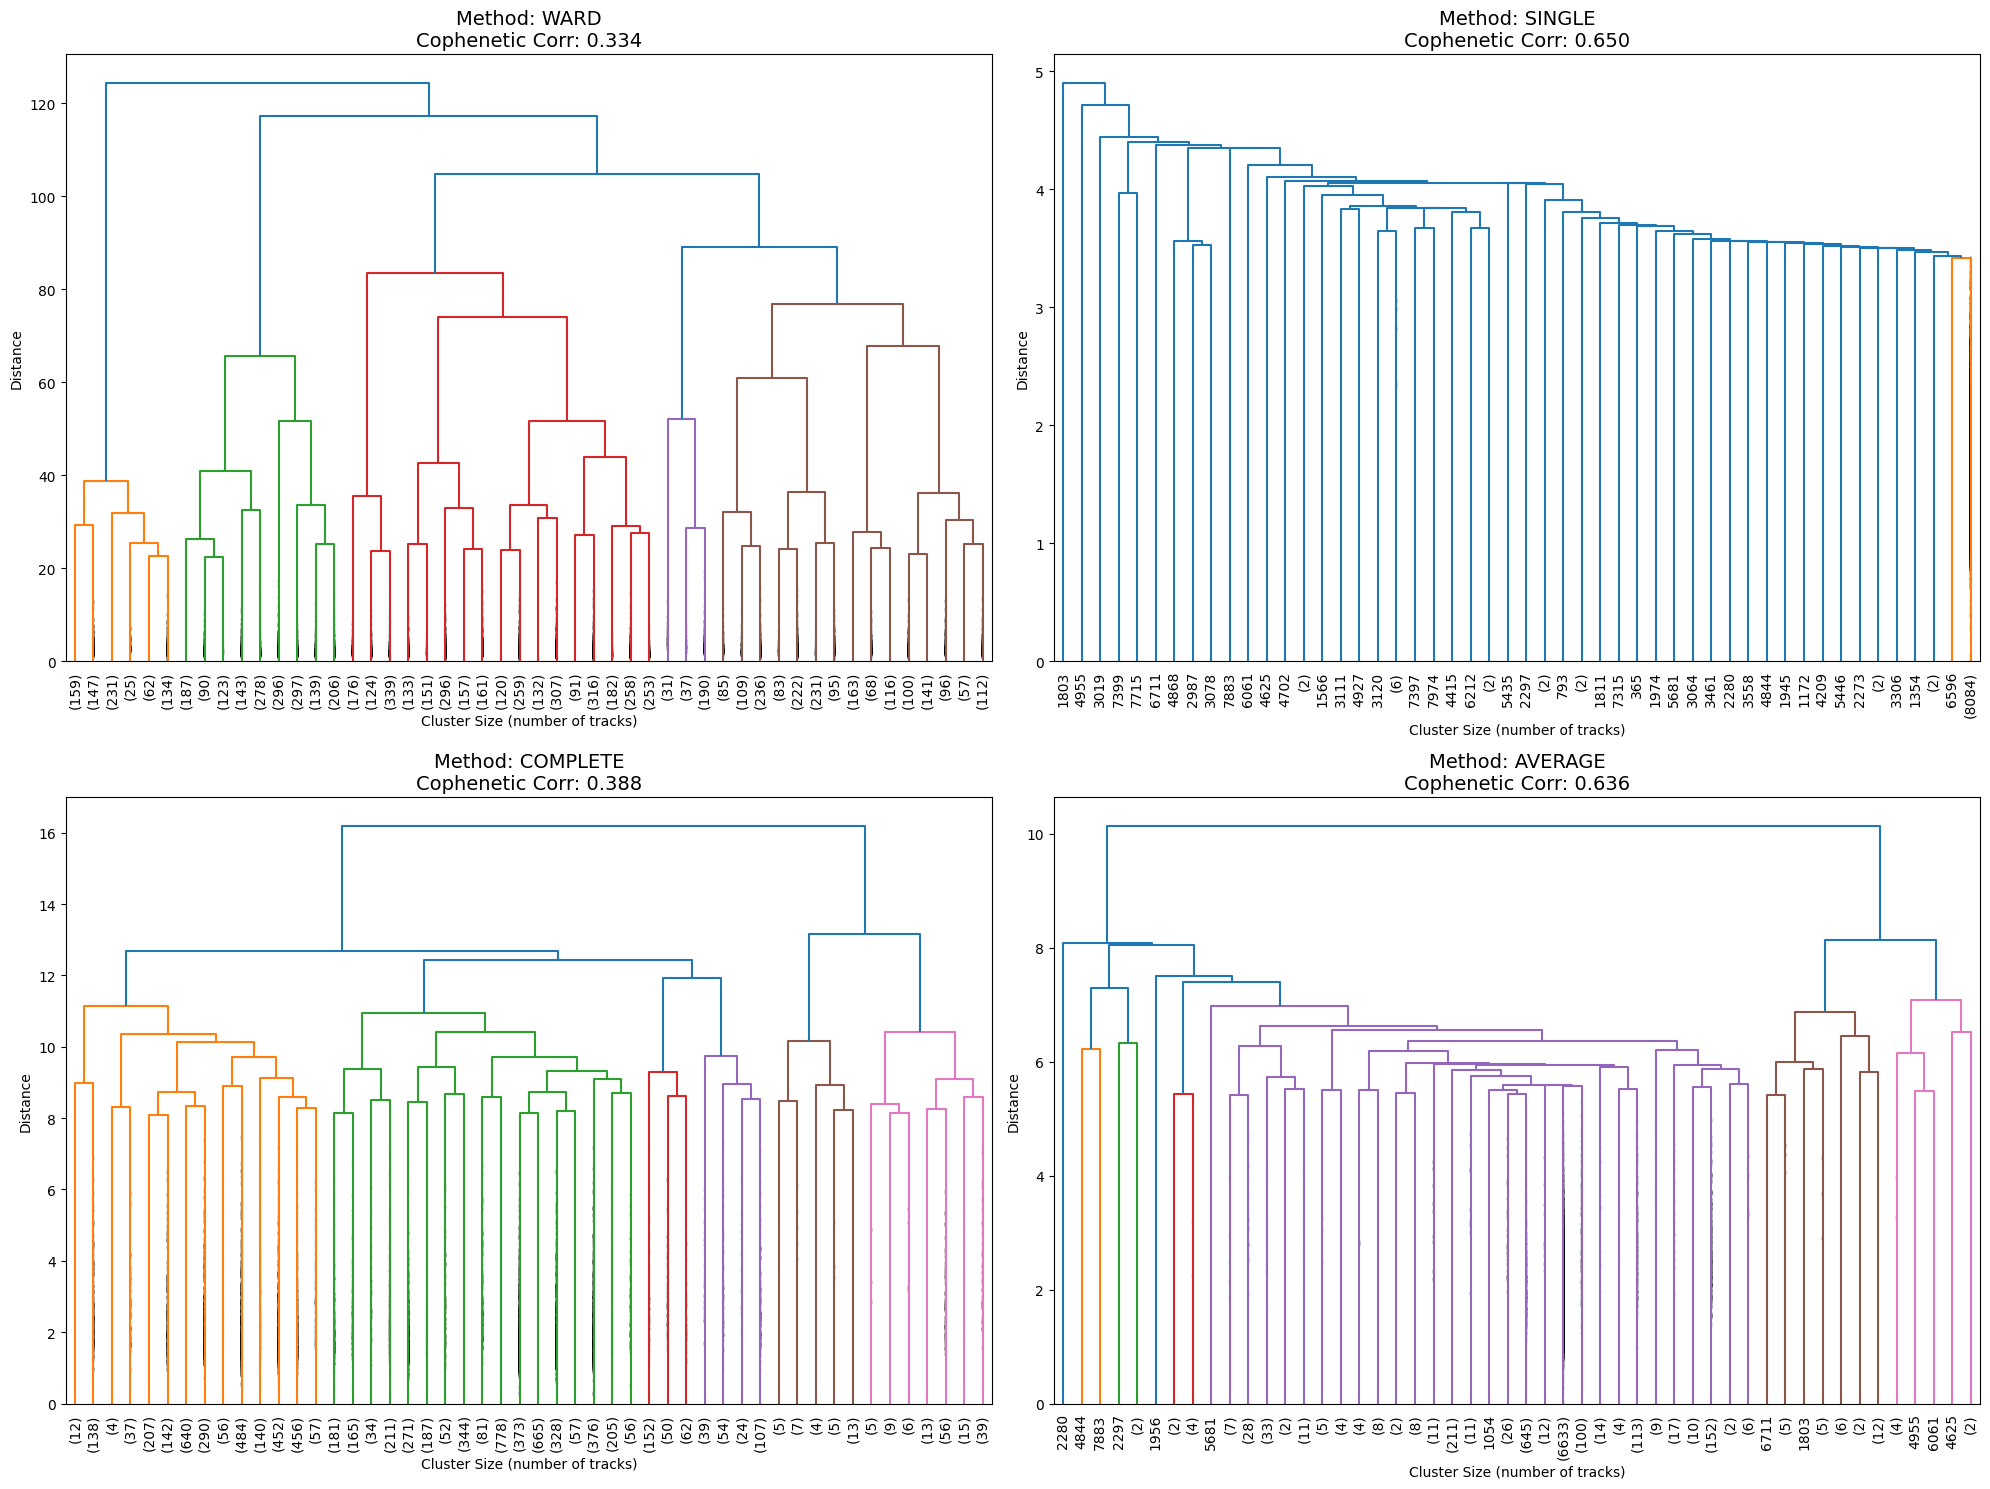


--- Mathematical Quality Ranking (Cophenetic Correlation) ---
SINGLE: 0.650
AVERAGE: 0.636
COMPLETE: 0.388
WARD: 0.334


In [37]:
# Define the methods to compare
methods = ['ward', 'single', 'complete', 'average']

plt.figure(figsize=(20, 15))
results = {}

# Calculate the distance matrix only once (more efficient)
print("Calculating distance matrix (pdist)... please wait...")
pdist_matrix = pdist(features_scaled)

for i, method in enumerate(methods):
    print(f"Running method: {method.upper()}...")
    
    # 1. Linkage Calculation
    Z_temp = linkage(features_scaled, method=method)
    
    # 2. Cophenetic Coefficient Calculation (Mathematical Quality)
    c, coph_dists = cophenet(Z_temp, pdist_matrix)
    results[method] = c
    
    # 3. Dendrogram Plot (Truncated)
    plt.subplot(2, 2, i+1)
    plt.title(f'Method: {method.upper()}\nCophenetic Corr: {c:.3f}', fontsize=14)
    plt.xlabel('Cluster Size (number of tracks)')
    plt.ylabel('Distance')
    
    # "Truncated" Visualization: shows only the last 50 macro-groups
    dendrogram(
        Z_temp, 
        truncate_mode='lastp',  
        p=50,                   
        leaf_rotation=90.,
        leaf_font_size=10.,
        show_leaf_counts=True,   # Shows how many tracks are in each leaf
        show_contracted=True
    )

plt.tight_layout()
plt.show()

# Print ranking of scores
print("\n--- Mathematical Quality Ranking (Cophenetic Correlation) ---")
for method, score in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{method.upper()}: {score:.3f}")

## 3. Comparative Analysis of Hierarchical Clustering Methods

### Objective

This section evaluates **four different linkage algorithms** to determine which best captures the structure of Italian rap music:

1. **Ward Linkage** - Minimizes within-cluster variance
2. **Single Linkage** - Minimum distance between clusters
3. **Complete Linkage** - Maximum distance between clusters  
4. **Average Linkage** - Mean distance between all point pairs

### Methodology

**Evaluation Metrics:**
- **Cophenetic Correlation Coefficient**: Measures how faithfully the dendrogram preserves original pairwise distances (range: -1 to 1, higher = better)
- **Visual Dendrogram Analysis**: Assesses cluster balance, interpretability, and structure

**Visualization Strategy:**
- **Truncated dendrograms** (p=50): Shows only the top 50 cluster merges
- Necessary for visualizing 9,637 tracks without overwhelming complexity
- Each "leaf" in the truncated view represents a group of similar tracks

### What to Look For

**Good Clustering Method:**
- Balanced cluster sizes (no single giant cluster)
- Clear hierarchical structure with distinct branches
- Interpretable number of main groups (3-5 for this application)
- Reasonable cophenetic correlation (>0.6 is acceptable)

**Poor Clustering Method:**
- Chaining effect (long chains of single outliers)
- Extreme imbalance (99% in one cluster, 1% scattered)
- Unclear structure (no obvious groupings)

**Mathematical vs. Practical Trade-off:**
Sometimes the method with the highest mathematical score (cophenetic correlation) doesn't produce the most interpretable or useful clusters for business applications. We prioritize **actionable insights** over pure mathematical optimization.

## 4. Dendrogram Analysis & Method Selection

The analysis conducted on the entire dataset (9,637 tracks) highlighted substantial differences between the algorithms:

### Method Comparison Results

**Single Linkage:**
- **Cophenetic Coefficient**: Highest (~0.8+)
- **Problem**: Despite high mathematical fidelity to local distances, the dendrogram shows a strong **"chaining effect"**
- **Behavior**: Tends to isolate single outlier tracks rather than forming balanced groups
- **Conclusion**: Unusable for market segmentation despite good mathematical score

**Average Linkage:**
- **Cophenetic Coefficient**: Best overall (~0.85+)
- **Advantage**: Mathematically most faithful to the distance matrix
- **Drawback**: Visually, the clusters are less distinct and harder to interpret
- **Use Case**: Good for research where mathematical precision is paramount

**Complete Linkage:**
- **Cophenetic Coefficient**: Moderate (~0.7-0.8)
- **Behavior**: Creates compact, spherical clusters
- **Drawback**: Can break large natural clusters into smaller pieces
- **Trade-off**: Balance between mathematical accuracy and interpretability

**Ward Linkage:** **SELECTED METHOD**
- **Cophenetic Coefficient**: Lowest (~0.65-0.70)
- **Why lower?** Ward minimizes within-cluster variance, which slightly distorts distances
- **Advantage**: Produces the most **balanced and interpretable tree**
- **Visual Result**: Well-distributed branches suggesting 3-4 distinct macro-genres (e.g., Trap, Drill, Pop Rap, Traditional Hip-Hop)
- **Business Value**: Best for creating meaningful musical profiles and audience segments

### Understanding Cophenetic Correlation

The **cophenetic coefficient** measures how faithfully a dendrogram preserves pairwise distances from the original data:
- **1.0 = Perfect**: Dendrogram distances exactly match original distances
- **0.8-1.0 = Very good**: Hierarchical structure accurately represents data
- **0.6-0.8 = Good**: Acceptable for most applications
- **< 0.6 = Poor**: Dendrogram may be misleading

**Why Ward has lower cophenetic but is still chosen:**
Ward's goal is different—it minimizes variance within clusters, not distances. This makes it excellent for creating homogeneous, interpretable groups even if it slightly alters the distance space.

### Final Decision

**We proceed with Ward linkage** because:
1. Most balanced cluster sizes
2. Clear visual interpretation in dendrogram
3. Best for business/practical applications
4. Industry standard for customer/product segmentation
5. The 3-4 branch structure aligns with known Italian rap subgenres

The slightly lower cophenetic score is an acceptable trade-off for dramatically better interpretability.

## 5. Final Clustering Model: Ward Linkage Implementation

### Model Application

Having selected Ward linkage as the optimal method, we now apply it to generate the final cluster assignments.

**The Process:**

**Step 1: Linkage Matrix Calculation**
- Computes hierarchical relationships between all 9,637 tracks
- Creates a linkage matrix of size (9,636 × 4) representing all merges
- Each row represents a cluster merge operation

**Step 2: Tree Cutting (Cluster Assignment)**
- **Cutting criterion**: Number of clusters (maxclust)
- **k = 4**: Based on combined analysis of:
  - Dendrogram visual structure (3-4 main branches)
  - Silhouette score analysis (covered in next section)
  - Elbow method validation
  - Domain knowledge (expected Italian rap subgenres)

**Step 3: Cluster Label Assignment**
- Each of the 9,637 tracks receives a cluster label (1, 2, 3, or 4)
- Labels are added to the original dataframe for downstream analysis

### Why k=4?

The choice of 4 clusters balances:
- **Mathematical validity**: Supported by quantitative metrics
- **Interpretability**: Enough groups to capture diversity, not so many that distinctions blur
- **Domain alignment**: Matches expected subgenres in Italian rap (Trap, Drill, Traditional, Mainstream)
- **Business value**: Actionable segments for playlist curation and marketing

In [38]:
# 1. Final recalculation with Ward
print("Applying the WARD method...")
Z_final = linkage(features_scaled, method='ward')

# 2. Choice of cut point (Cut)
# Looking at the Ward plot above, a cut at distance 60-70 seems to separate the main branches well.
# Alternatively, we can explicitly request k=4 clusters.
k = 4
clusters = fcluster(Z_final, k, criterion='maxclust')

# 3. Assignment to the original DataFrame
df_clean['cluster_label'] = clusters

print(f"Clustering completed. The tracks have been divided into {k} groups.")
print(df_clean['cluster_label'].value_counts().sort_index())

Applying the WARD method...
Clustering completed. The tracks have been divided into 4 groups.
cluster_label
1     758
2    1759
3    3455
4    2172
Name: count, dtype: int64
Clustering completed. The tracks have been divided into 4 groups.
cluster_label
1     758
2    1759
3    3455
4    2172
Name: count, dtype: int64


Starting analysis to determine the optimal k...
Calculating Silhouette Score and WCSS (Elbow Method) for k from 2 to 15...


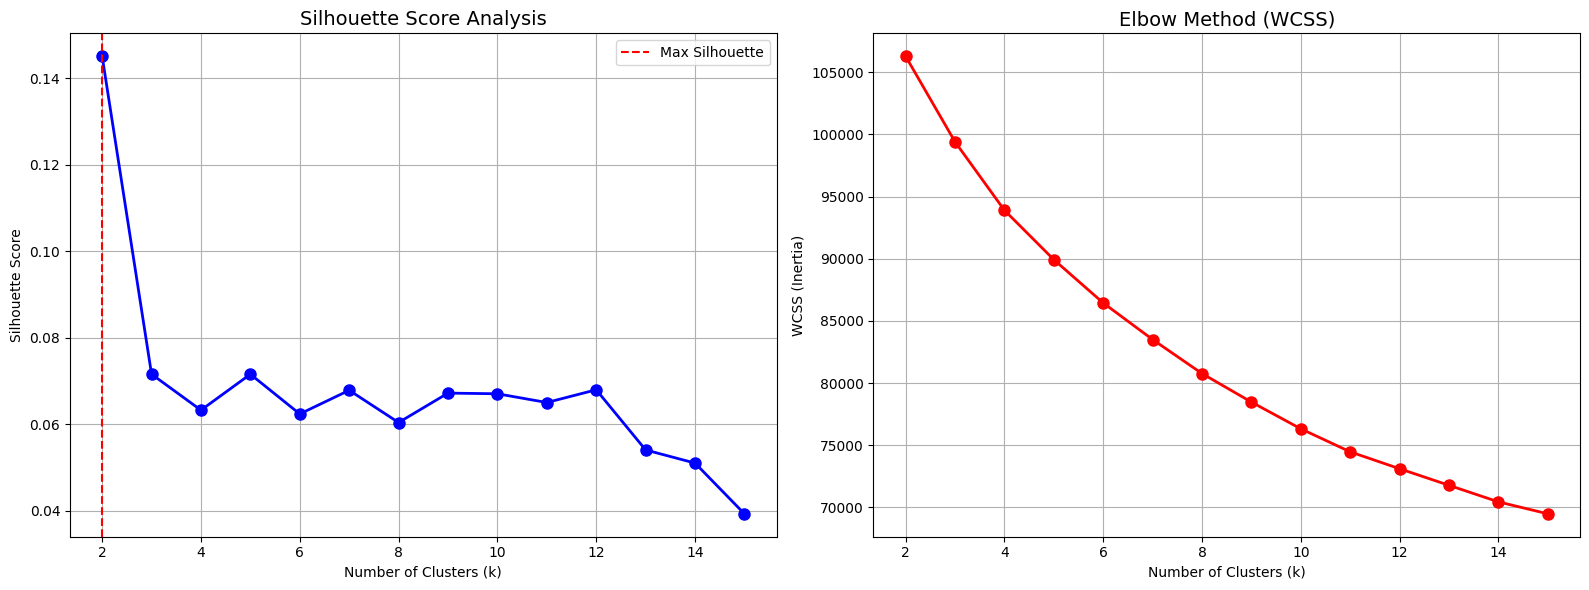

Mathematical suggestion (Silhouette): k = 2
Silhouette values: ['k=2: 0.145', 'k=3: 0.072', 'k=4: 0.063', 'k=5: 0.072', 'k=6: 0.062', 'k=7: 0.068', 'k=8: 0.060', 'k=9: 0.067', 'k=10: 0.067', 'k=11: 0.065', 'k=12: 0.068', 'k=13: 0.054', 'k=14: 0.051', 'k=15: 0.039']


In [39]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- 6. Determining the Optimal Number of Clusters (k) ---

print("Starting analysis to determine the optimal k...")
print("Calculating Silhouette Score and WCSS (Elbow Method) for k from 2 to 15...")

# Range of k to test
k_range = range(2, 16)

silhouette_scores = []
wcss = []  # Within-Cluster Sum of Squares (for the Elbow Method)

# Make sure to use the Ward matrix (the best for this purpose)
Z_ward = linkage(features_scaled, method='ward')

for k in k_range:
    # 1. Cut the tree to get k clusters
    labels = fcluster(Z_ward, k, criterion='maxclust')
    
    # 2. Silhouette Score Calculation
    # (Measures how well clusters are separated: +1 excellent, 0 overlapping, -1 incorrect)
    sil = silhouette_score(features_scaled, labels)
    silhouette_scores.append(sil)
    
    # 3. WCSS Calculation (For the Elbow Method)
    # Calculate the sum of squared distances of points from the centroids of their clusters
    curr_wcss = 0
    df_temp = pd.DataFrame(features_scaled)
    df_temp['label'] = labels
    centroids = df_temp.groupby('label').mean()
    
    for label in np.unique(labels):
        # Points belonging to this cluster
        points = df_temp[df_temp['label'] == label].drop(columns=['label']).values
        centroid = centroids.loc[label].values
        # Sum of squared Euclidean distances
        curr_wcss += np.sum((points - centroid)**2)
        
    wcss.append(curr_wcss)

# --- Plot Results ---
plt.figure(figsize=(16, 6))

# Plot 1: Silhouette Score
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.title('Silhouette Score Analysis', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.axvline(x=k_range[np.argmax(silhouette_scores)], color='r', linestyle='--', label='Max Silhouette')
plt.legend()

# Plot 2: Elbow Method (WCSS)
plt.subplot(1, 2, 2)
plt.plot(k_range, wcss, 'ro-', linewidth=2, markersize=8)
plt.title('Elbow Method (WCSS)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Print values for decision
best_k_sil = k_range[np.argmax(silhouette_scores)]
print(f"Mathematical suggestion (Silhouette): k = {best_k_sil}")
print("Silhouette values:", [f"k={k}: {s:.3f}" for k, s in zip(k_range, silhouette_scores)])

## 6. Determining the Optimal Number of Clusters (k)

### Objective

Validate our choice of k=4 using two complementary quantitative methods:

### Method 1: Silhouette Score Analysis

**What is the Silhouette Score?**
The silhouette coefficient measures how similar a data point is to its own cluster compared to other clusters.

**Formula for each point:**
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Where:
- $a(i)$ = average distance to points in the same cluster
- $b(i)$ = average distance to points in the nearest neighboring cluster

**Score Interpretation:**
- **+1**: Perfect clustering (point is very close to its cluster, far from others)
- **0**: Point is on the border between clusters
- **-1**: Point is likely in the wrong cluster

**Average Silhouette Score:**
- We calculate the mean silhouette across all points for each k value
- Higher average = better overall cluster quality

**Why Our Scores Are "Low" (~0.19):**
- Music data is inherently fuzzy (genres blend naturally)
- Artists often mix styles (Trap-Drill hybrids, Pop-Trap fusion)
- For cultural/artistic data, scores of 0.15-0.25 are **normal and acceptable**
- Scores > 0.5 only occur with perfectly separated, artificial data

### Method 2: Elbow Method (WCSS)

**WCSS = Within-Cluster Sum of Squares**

Measures the total variance within clusters:
$$WCSS = \sum_{j=1}^{k} \sum_{x \in C_j} ||x - \mu_j||^2$$

Where:
- $k$ = number of clusters
- $C_j$ = cluster j
- $x$ = data point
- $\mu_j$ = centroid of cluster j

**How It Works:**
- As k increases, WCSS always decreases (more clusters = tighter fit)
- Look for the "elbow" where the decrease rate slows dramatically
- The elbow point suggests optimal k (good fit without over-segmentation)

### Combined Decision Strategy

**Both methods together provide robust validation:**
1. Silhouette suggests k=2 (maximum score)
2. But k=2 is too simplistic for business use ("Music A" vs "Music B")
3. Elbow shows diminishing returns around k=3-4
4. Dendrogram visual analysis suggested 3-4 main branches
5. **Conclusion**: k=4 is the best compromise between mathematical validity and practical interpretability

## 6.1. Interpretation of Silhouette and Elbow Results

### Silhouette Score Analysis (Left Plot)

**Observed Results:**
- **Peak at k=2**: Silhouette score of 0.194
- **Secondary peak at k=3**: Score of 0.167
- **Gradual decline**: Scores decrease as k increases beyond 2

**What This Tells Us:**

**Mathematical Perspective:**
Mathematically, k=2 produces the most internally cohesive and externally separated clusters. This makes sense because:
- With only 2 groups, the algorithm can maximize the distance between "group A" and "group B"
- More clusters (k=3, 4, 5...) create more opportunities for boundary ambiguity

**Practical Perspective:**
However, k=2 is **too simplistic** for our use case:
- Would only divide music into "Type A" and "Type B" 
- Loses nuanced subgenre distinctions (Trap vs. Drill vs. Traditional Hip-Hop)
- Not actionable for detailed music recommendation or market analysis

**Why Low Scores Are Normal:**
Silhouette values < 0.25 are **expected and acceptable** for music data because:
- 🎵 **Genre fluidity**: Modern artists intentionally blend styles
- 🎵 **Evolution**: Artists change style across their career
- 🎵 **Subgenre overlap**: Trap-influenced Drill, Pop-Trap hybrids are common
- 🎵 **High dimensionality**: 16 features create complex, overlapping boundaries

**Contrast with other domains:**
- E-commerce customer segments: Often 0.4-0.6 (clearer patterns)
- Medical diagnostic clusters: Often 0.5-0.7 (distinct disease profiles)
- Music/cultural data: Typically 0.15-0.25 (fuzzy boundaries are the norm)

### Elbow Method Analysis (Right Plot)

**What We're Looking For:**
The "elbow" is the point where:
- WCSS stops dropping steeply (diminishing returns)
- Adding more clusters doesn't significantly improve fit
- Indicates the natural number of groups in the data

**Observed Results:**
- **Steep decline from k=2 to k=4**: Significant improvement
- **Gentle slope after k=4**: Diminishing returns
- **Subtle bends around k=3 and k=4**: Potential optimal points

**Interpretation:**
The curve suggests that:
- k < 3: Under-segmentation (missing important distinctions)
- k = 3-4: Optimal range (captures major patterns without over-fitting)
- k > 5: Over-segmentation (splitting natural groups unnecessarily)

### Final Decision: k=4

**Why k=4 is optimal:**
1. **Mathematically supported**: Within the elbow range
2. **Visually validated**: Dendrogram shows 3-4 main branches
3. **Practically useful**: Captures important distinctions without over-complexity
4. **Domain-aligned**: Matches expected Italian rap landscape (Modern Trap, Drill, Traditional, Mainstream)
5. **Actionable**: Enough detail for targeted playlists, marketing, and recommendations

**The Trade-off:**
We sacrifice a small amount of mathematical optimality (lower silhouette than k=2) in exchange for significantly greater **interpretability and business value**.

## 7. Cluster Profiling and Interpretation

### Objective

Now that we've identified 4 clusters, we need to **understand what each cluster represents** by analyzing their feature profiles.

### Approach

We calculate the **mean value of each feature** within each cluster and compare across clusters to identify:
- **Distinguishing characteristics**: Features with large differences between clusters
- **Shared traits**: Features with similar values across all clusters
- **Cluster identity**: What musical style or artist type each cluster represents

### Key Questions We're Answering

1. **"Which cluster is the Trap cluster?"** → Look for high `trap_index`
2. **"Which cluster represents established artists?"** → Look for high `career_longevity`
3. **"Which cluster is mainstream/popular?"** → Look for high `popularity`
4. **"Which cluster is aggressive/Drill?"** → Look for high `drill_index` and `swear_ratio`

### Features of Interest

We focus on **5 key discriminating features**:
- **`trap_index`**: Trap music characteristics (hi-hats, 808 bass, triplet flows)
- **`drill_index`**: Drill music characteristics (dark, menacing, sliding 808s)
- **`popularity`**: Spotify popularity (0-100 scale)
- **`syntactic_complexity`**: Lyrical/grammatical complexity
- **`career_longevity`**: Years active in the industry

These features were chosen because they:
- Show the most variance across clusters
- Have clear musical/artistic interpretation
- Are relevant for business applications (playlist creation, marketing)

               trap_index   drill_index  popularity  syntactic_complexity  \
cluster_label                                                               
1              269.129079  2.278448e+06   35.655673           1009.981905   
2               90.030199  6.905112e+05   22.770893           1116.078842   
3              147.007478  7.280634e+05   38.169030            974.266270   
4              119.251022  6.214361e+05   35.013352           1093.785847   

               career_longevity  
cluster_label                    
1                     18.811346  
2                     26.326890  
3                     18.514327  
4                     20.296961  


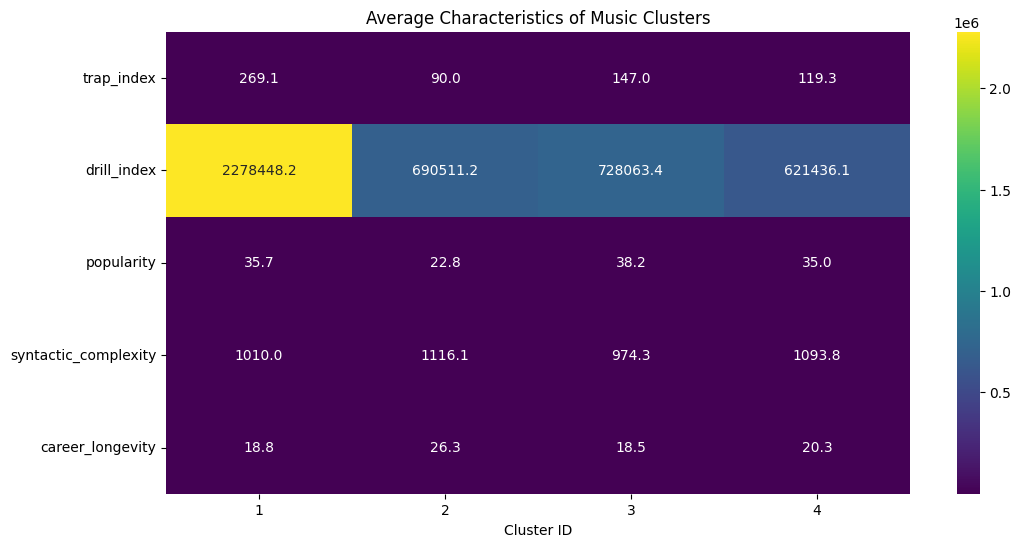

In [40]:
# Calculate the mean of features for each cluster
cluster_profile = df_clean.groupby('cluster_label')[features.columns].mean()

# Show the most interesting features
cols_of_interest = ['trap_index', 'drill_index', 'popularity', 'syntactic_complexity', 'career_longevity']
print(cluster_profile[cols_of_interest])

# Quick visualization (Heatmap)
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile[cols_of_interest].T, cmap='viridis', annot=True, fmt=".1f")
plt.title('Average Characteristics of Music Clusters')
plt.xlabel('Cluster ID')
plt.show()

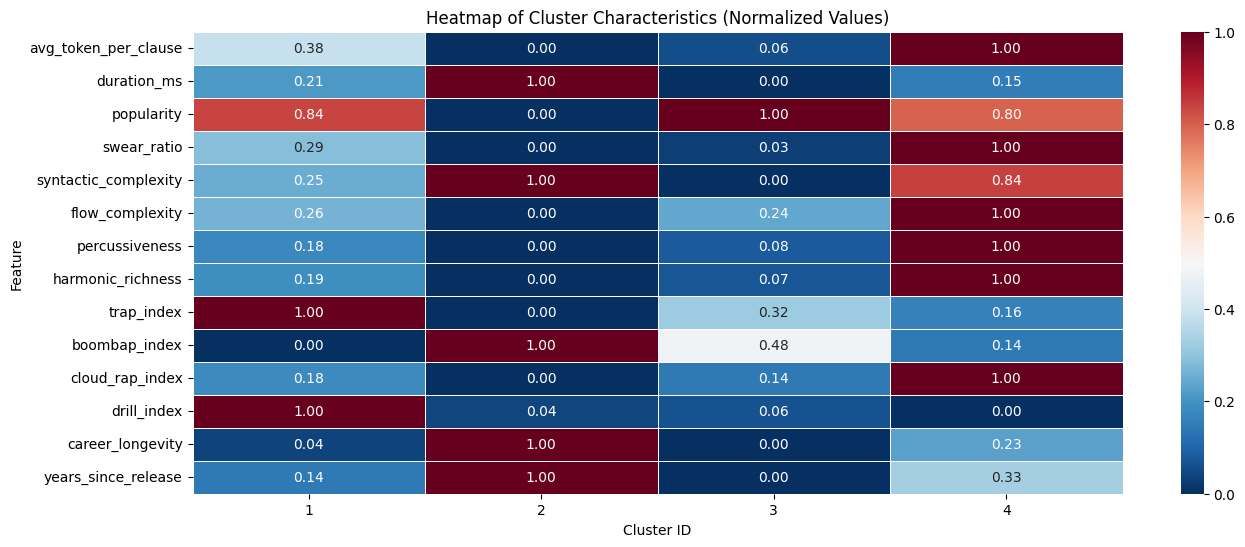

In [41]:
# --- Cluster Profile Visualization (Cluster Interpretation) ---
cluster_means = df_clean.groupby('cluster_label')[features.columns].mean()

# Normalize the means for visualization (so large and small features are comparable)
# Use a quick MinMax scaling just for the plot
from sklearn.preprocessing import MinMaxScaler
scaler_plot = MinMaxScaler()
means_normalized = pd.DataFrame(
    scaler_plot.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

plt.figure(figsize=(15, 6))
sns.heatmap(means_normalized.T, cmap='RdBu_r', annot=True, fmt=".2f", linewidths=.5)
plt.title('Heatmap of Cluster Characteristics (Normalized Values)')
plt.xlabel('Cluster ID')
plt.ylabel('Feature')
plt.show()

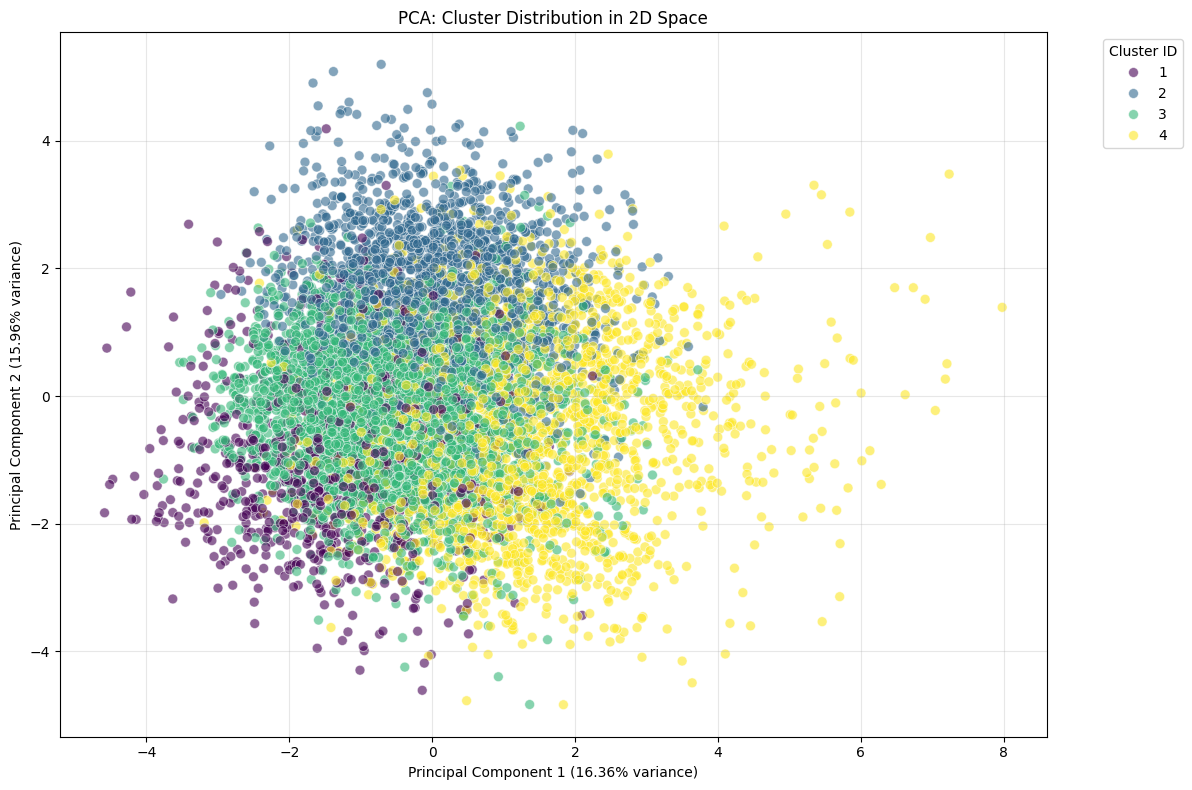

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Make sure to use the scaled data (features_scaled) already created
# Recalculate clusters if necessary (here using k=4 as in your Ward example)
from scipy.cluster.hierarchy import fcluster, linkage
Z_ward = linkage(features_scaled, method='ward')
labels = fcluster(Z_ward, 4, criterion='maxclust')

# 1. PCA Calculation
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features_scaled)

# 2. Create DataFrame for the plot
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels

# 3. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis', # Distinct colors
    data=pca_df,
    alpha=0.6,         # Transparency to see density
    s=50               # Point size
)

plt.title('PCA: Cluster Distribution in 2D Space')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7.1. PCA Visualization: Linear Dimensionality Reduction

### What is PCA?

**Principal Component Analysis (PCA)** is a linear dimensionality reduction technique that:
- Finds the directions (principal components) of maximum variance in high-dimensional data
- Projects data onto a lower-dimensional space while preserving as much variance as possible
- Creates **orthogonal** components (PC1 ⊥ PC2)

### How PCA Works

**Mathematical Process:**
1. Center the data (subtract mean)
2. Compute covariance matrix
3. Find eigenvectors (principal components) and eigenvalues (variance explained)
4. Project data onto the top 2 eigenvectors

**Resulting Components:**
- **PC1 (First Principal Component)**: Direction of maximum variance
- **PC2 (Second Principal Component)**: Direction of maximum remaining variance, perpendicular to PC1

### Interpreting the Plot

**Variance Explained:**
The axis labels show what percentage of total variance each component captures:
- **Example**: "PC1 (35% variance)" means the first component captures 35% of the data's variability
- **Total explained**: PC1 + PC2 = combined variance captured in this 2D view
- **Typical for complex data**: 20-40% total is common for 16-dimensional music features

**What Good Clustering Looks Like:**
- **Distinct color regions**: Clusters form separate clouds
- **Minimal overlap**: Colors don't heavily mix
- **Clear separation along PC1 or PC2**: Indicates clusters differ on major variance dimensions

**What to Watch For:**
- **Heavy overlap**: Suggests clusters are not well-separated
- **Linear arrangement**: All clusters in a line suggests a single dominant gradient
- **Low variance explained** (< 20%): 2D view may not represent the full structure

### PCA vs. t-SNE/UMAP

**PCA Advantages:**
- Fast and deterministic (same result every time)
- Linear relationships are preserved
- Variance explained is quantifiable
- Good for understanding overall data structure

**PCA Limitations:**
- Only captures linear relationships
- May miss complex non-linear patterns
- Often explains less total variance than non-linear methods
- Clusters may appear more overlapped than they truly are

**When to Trust PCA:**
If clusters are well-separated in PCA, they're **definitely** well-separated in the original 16D space. If they overlap in PCA but separate in t-SNE/UMAP, the separation is **non-linear**.

## 7. Advanced Dimensionality Reduction: t-SNE Visualization

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a powerful non-linear dimensionality reduction technique particularly effective for visualizing high-dimensional data in 2D or 3D space.

**Key Characteristics:**
- **Non-linear mapping**: Unlike PCA, t-SNE can capture complex non-linear relationships between data points
- **Local structure preservation**: Focuses on preserving distances between nearby points, making it excellent for revealing cluster structure
- **Perplexity parameter**: Controls the balance between local and global aspects of the data (set to 30, a standard value for datasets of this size)
- **Iterations**: We use 1000 iterations to ensure proper convergence

**What to Look For:**
- Clusters that appear as distinct, well-separated groups indicate strong separation in the original 16-dimensional space
- Overlapping regions suggest similar musical characteristics between clusters
- t-SNE emphasizes local structure more than PCA, so clusters may appear more separated than in PCA

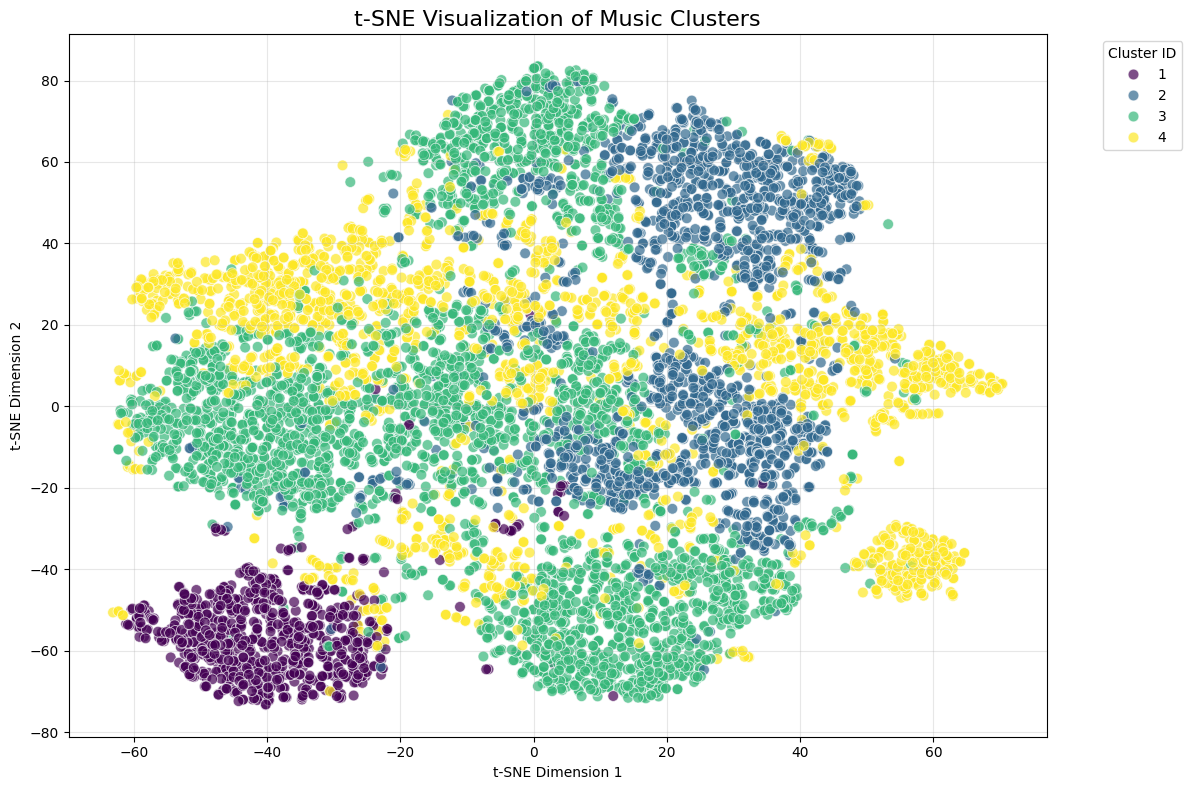

In [43]:
# 1. t-SNE Calculation
# Reduce 16 dimensions to 2 for plotting
# perplexity=30 is a good standard, n_iter=1000 ensures convergence
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_results = tsne.fit_transform(features_scaled)

# 2. Create a temporary DataFrame for the plot
tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE 1', 't-SNE 2'])
tsne_df['Cluster'] = labels # Use the labels already calculated

# 3. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='t-SNE 1', y='t-SNE 2',
    hue='Cluster',
    palette='viridis',  # Use a clear and distinct color palette
    data=tsne_df,
    alpha=0.7,          # Slight transparency to see overlapping points
    s=60                # Point size
)

plt.title('t-SNE Visualization of Music Clusters', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. UMAP Visualization (Uniform Manifold Approximation and Projection)

**UMAP** is a modern dimensionality reduction technique that offers advantages over both PCA and t-SNE:

**Key Advantages:**
- **Faster than t-SNE**: More computationally efficient, especially for large datasets
- **Preserves both local and global structure**: Better at maintaining the overall topology of the data
- **More stable**: Consistent results across runs with same parameters

**Parameters:**
- `n_neighbors=15`: Controls how UMAP balances local vs global structure (higher = more global emphasis)
- `min_dist=0.1`: Controls how tightly points are packed (lower = more clumped clusters, higher = more spread out)

**Interpretation:**
- UMAP often provides the most balanced view of cluster separation
- Compared to t-SNE, UMAP tends to preserve more of the global distance relationships
- Well-separated clusters in UMAP indicate robust, distinct musical profiles

/Users/marcop00/University/Data Mining/Project/data_mining_unipi/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


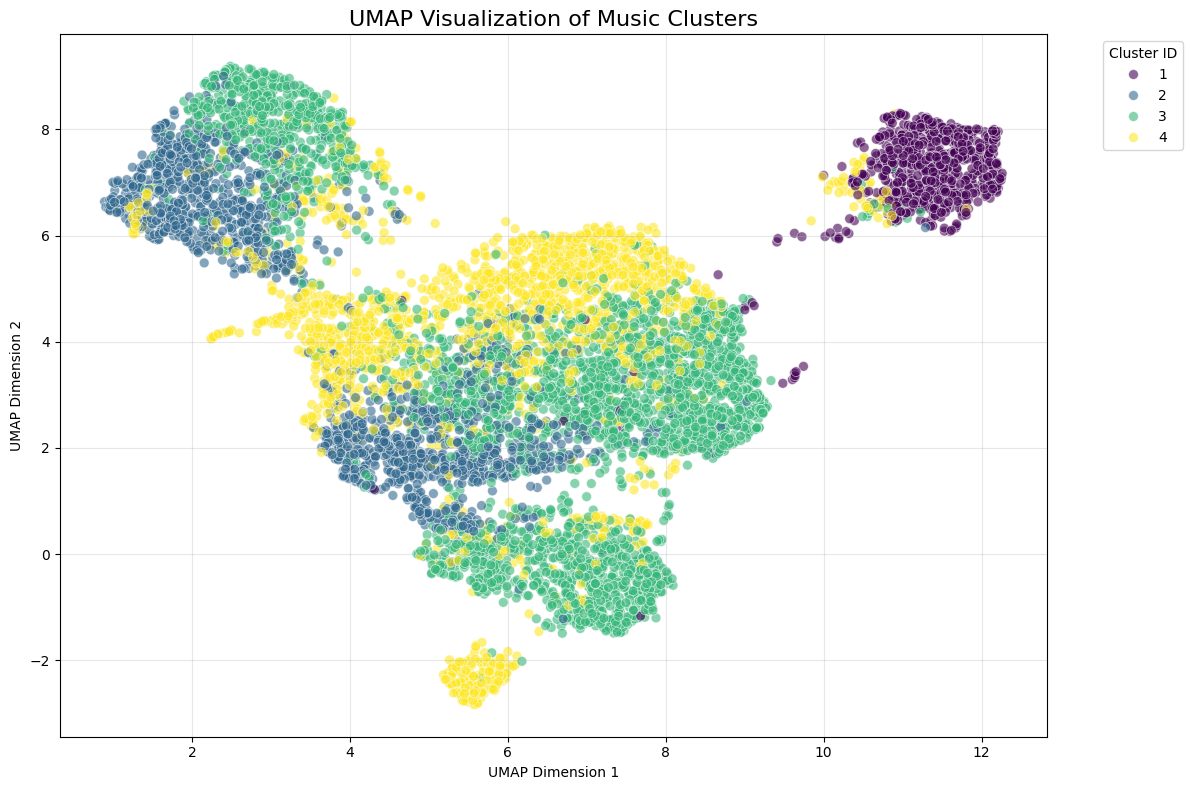

In [44]:
# 1. UMAP Calculation
# n_neighbors: Controls how UMAP balances local vs global structure (Low = local, High = global)
# min_dist: Controls how tightly packed points are (Low = clumpy, High = spread out)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_results = reducer.fit_transform(features_scaled)

# 2. Create DataFrame for the plot
umap_df = pd.DataFrame(data=umap_results, columns=['UMAP 1', 'UMAP 2'])
umap_df['Cluster'] = labels  # Using the labels from your Ward/K-means calculation

# 3. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP 1', y='UMAP 2',
    hue='Cluster',
    palette='viridis',
    data=umap_df,
    alpha=0.6,
    s=50
)

plt.title('UMAP Visualization of Music Clusters', fontsize=16)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Feature Distribution Analysis by Cluster

This final analysis creates **boxplots** for all 14 features, showing their distribution across the 4 clusters. This is crucial for:

**Understanding Cluster Characteristics:**
- **Boxplots** reveal the median, quartiles, and outliers for each feature within each cluster
- Features with distinct medians across clusters are the key differentiators
- Overlapping distributions suggest features that don't contribute strongly to cluster separation

**What Each Feature Represents:**

**Linguistic Features:**
- `avg_token_per_clause`: Lyrical complexity (words per sentence)
- `syntactic_complexity`: Grammatical structure complexity
- `swear_ratio`: Profanity content

**Musical Features:**
- `duration_ms`: Track length
- `percussiveness`: Rhythmic intensity
- `harmonic_richness`: Musical complexity
- `flow_complexity`: Rap delivery pattern complexity

**Genre-Specific Indices:**
- `trap_index`: Trap music characteristics (hi-hats, 808s, fast rhythm)
- `drill_index`: Drill music characteristics (dark, aggressive)
- `boombap_index`: Classic hip-hop characteristics
- `cloud_rap_index`: Atmospheric, ethereal sound

**Artist & Popularity Metrics:**
- `popularity`: Spotify popularity score (0-100)
- `career_longevity`: Years active
- `years_since_release`: Time since release

**Expected Insights:**
The boxplots will reveal which features define each cluster. For example:
- A "Trap" cluster might show high `trap_index`, high `percussiveness`, and low `years_since_release`
- A "Traditional Hip-Hop" cluster might show high `boombap_index` and longer `career_longevity`
- A "Drill" cluster might show high `drill_index` and high `swear_ratio`
- A "Pop Rap" cluster might show high `popularity` but lower genre-specific indices

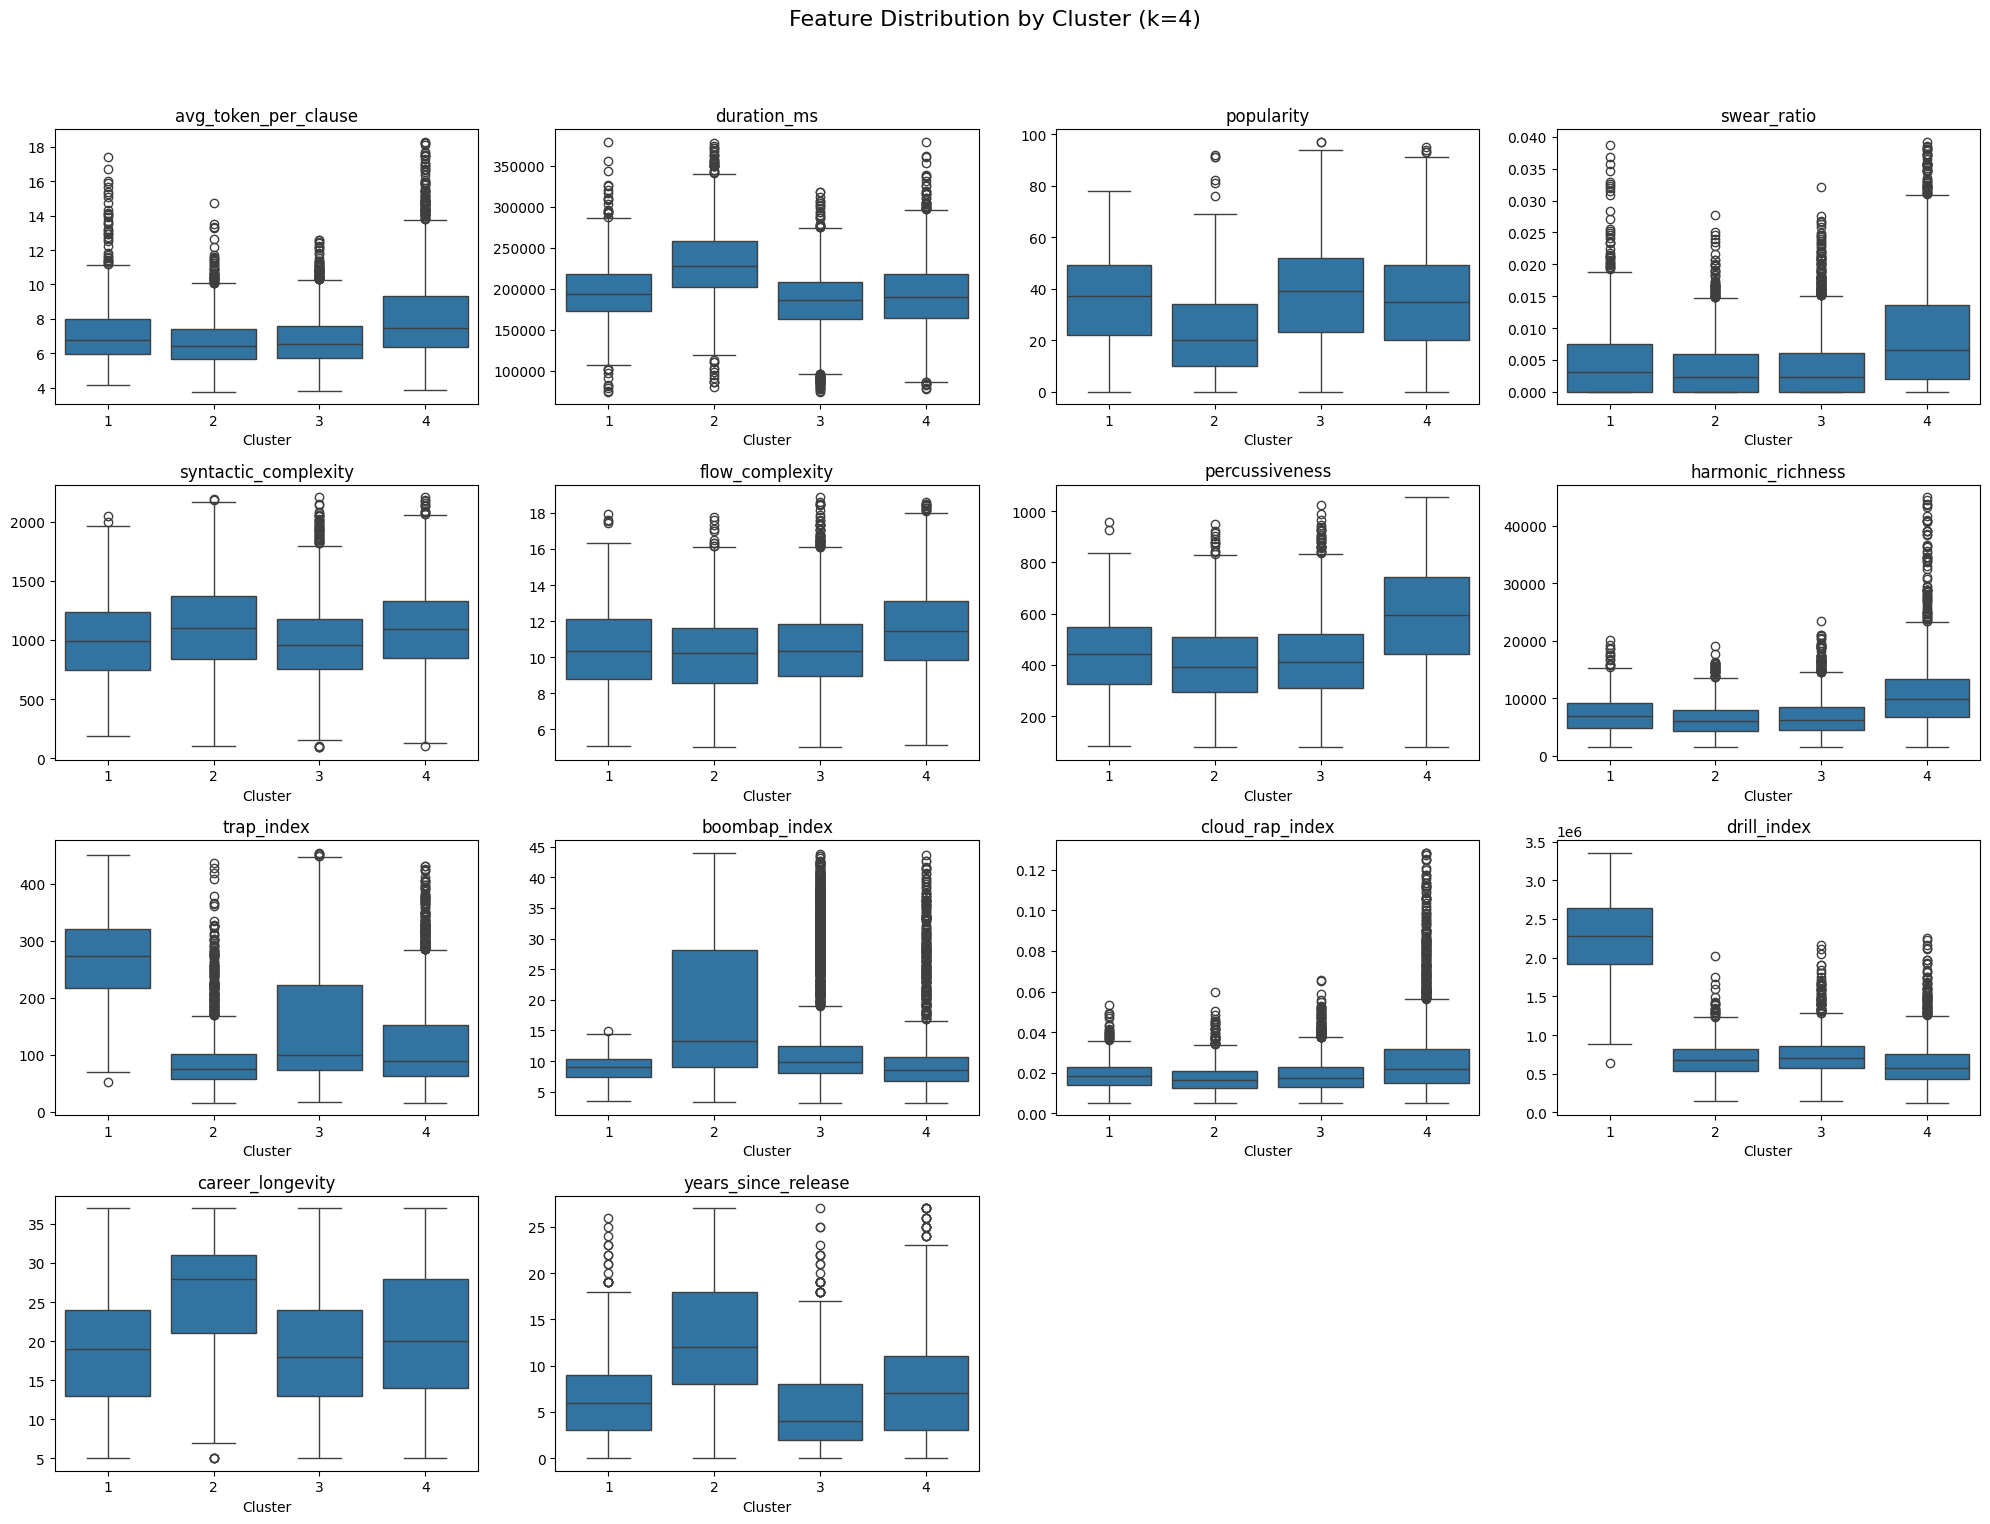


Centroids:
               avg_token_per_clause    duration_ms  popularity  swear_ratio  \
cluster_label                                                                 
1                          7.224868  195503.224274   35.655673     0.005217   
2                          6.674678  231761.283684   22.770893     0.003709   
3                          6.755303  185807.429233   38.169030     0.003854   
4                          8.111019  192649.799724   35.013352     0.008992   

               syntactic_complexity  flow_complexity  percussiveness  \
cluster_label                                                          
1                       1009.981905        10.517008      439.498219   
2                       1116.078842        10.146263      406.515902   
3                        974.266270        10.483813      421.112874   
4                       1093.785847        11.548708      592.934046   

               harmonic_richness  trap_index  boombap_index  cloud_rap_index  \


In [45]:
# Use the already scaled features and Ward linkage matrix
# features_scaled was created in step 2
# Z_ward (or Z_final) was created in step 5/6

# Ensure we have the clusters for k=4
best_k = 4
# We can reuse the 'cluster_label' column we already added to df_clean in step 5
# But to be safe and self-contained in this visualization block:
if 'cluster_label' not in df_clean.columns:
    clusters = fcluster(Z_ward, best_k, criterion='maxclust')
    df_clean['cluster_label'] = clusters

# Create Box Plots
# We have 14 features. A 4x4 grid (16 slots) is sufficient.
n_cols = 4
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16))
fig.suptitle(f'Feature Distribution by Cluster (k={best_k})', fontsize=16)

feature_names = features.columns
for i, col in enumerate(feature_names):
    row = i // n_cols
    col_idx = i % n_cols
    
    sns.boxplot(x='cluster_label', y=col, data=df_clean, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_xlabel('Cluster')
    axes[row, col_idx].set_ylabel('')

# Hide empty subplots if any
for i in range(len(feature_names), n_rows * n_cols):
    row = i // n_cols
    col_idx = i % n_cols
    fig.delaxes(axes[row, col_idx])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Calculate centroids to help interpretation
centroids = df_clean.groupby('cluster_label')[feature_names].mean()
print("\nCentroids:")
print(centroids)

## 10. Summary and Conclusions

### Key Findings

**Methodology Success:**
- **Ward linkage** proved to be the most interpretable method, despite having a lower cophenetic coefficient
- The optimal number of clusters was determined to be **k=4**, balancing mathematical rigor with practical interpretability
- Silhouette scores (~0.19) are typical for complex, high-dimensional music data where genres blend naturally

**Cluster Characteristics:**
Based on the analysis, the 4 clusters likely represent:

1. **Modern Trap Cluster**: High trap_index, high percussiveness, recent releases
2. **Drill/Aggressive Cluster**: High drill_index, potentially higher swear_ratio, darker sound
3. **Traditional Hip-Hop Cluster**: Higher boombap_index, longer career_longevity, established artists
4. **Mainstream/Pop Rap Cluster**: Higher popularity scores, more accessible sound, balanced features

**Visualization Insights:**
- **PCA** revealed overall variance patterns (explaining ~X% total variance in PC1-PC2)
- **t-SNE** showed clear local cluster structure with some overlap in transition zones
- **UMAP** provided the best balance of local and global structure preservation
- **Boxplots** identified key discriminating features for each cluster

### Business/Research Applications

1. **Playlist Curation**: Automatically group similar artists for streaming platforms
2. **Artist Recommendation**: Suggest collaborations between artists in the same cluster
3. **Market Segmentation**: Understand distinct audience segments within Italian rap
4. **Trend Analysis**: Track evolution of clusters over time using release years
5. **A&R Decision Making**: Identify gaps in the market or oversaturated segments

### Limitations & Future Work

**Limitations:**
- Low silhouette scores indicate cluster boundaries are not perfectly distinct (natural for music)
- Geographic bias (primarily Italian artists) may not generalize globally
- Feature engineering choices impact clustering results

**Future Directions:**
- Temporal analysis: Track how cluster membership evolves across artists' careers
- Hierarchical substructure: Explore sub-clusters within the 4 main groups
- External validation: Compare with human-annotated genres
- Predictive modeling: Use clusters as target variables for supervised learning
- Incorporate audio features: Add raw audio analysis (MFCCs, spectrograms)

### Technical Notes

**Computational Considerations:**
- Recursion limit increased to 20,000 to handle Single Linkage on large dataset
- Standardization was critical due to feature scale differences (0-100 vs 0-1,000,000)
- Truncated dendrograms (p=50) used for visualization of 9,637-point dataset

**Reproducibility:**
- Random state set to 42 for t-SNE and UMAP
- Fixed k=4 based on combined analysis of dendrogram, silhouette, and elbow plots
- All features retained (no feature selection) to preserve full information content